# Image Augmentation: Introduction

## What is Image Augmentation?

Image augmentation is a technique where we **modify images slightly** to create new versions.  
This helps models **see more variety** and **generalize better**, especially if the dataset is small.

### Example Simple Transformations

- **Flip**: Horizontally or vertically  
- **Rotation**: Rotate the image a few degrees  
- **Color jitter**: Slightly change brightness, contrast, saturation  
- **Crop / Resize**: Randomly crop or resize  


## Step 1: Load and Display an Image

Before applying any augmentation, we first need to load the image.  
We'll use the **PIL (Python Imaging Library)** to open the image and **matplotlib** to visualize it.  

This same image will be used throughout all augmentation examples.


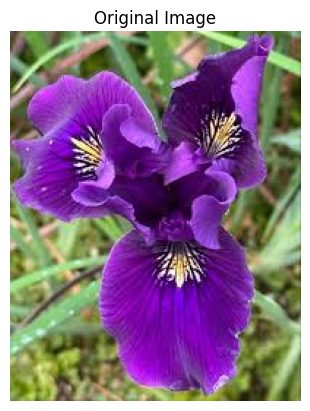

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "./iris.jpeg"
image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()


## Step 2: Horizontal Flip

**Horizontal Flip** mirrors the image along the vertical axis.  

- **Why use it?**  
  Makes the model robust to left-right variations.  
  For example, if you have pictures of cats facing right, flipping creates examples of cats facing left.

- **Adjustable parameter:**  
  `p` = probability of applying the flip.  
  - `p=0.0` → never flip  
  - `p=0.5` → flip half of the time  
  - `p=1.0` → always flip


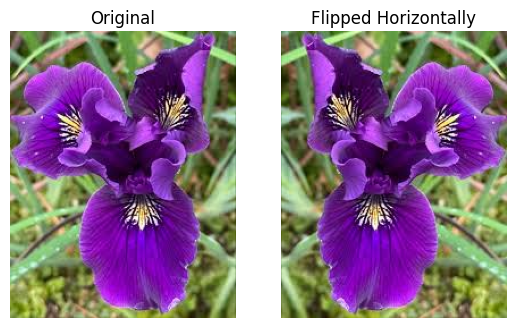

In [13]:
from torchvision import transforms
import matplotlib.pyplot as plt

# Defining horizontal flip transform
horizontal_flip = transforms.RandomHorizontalFlip(p=1.0)

# Applying transformation
flipped_image = horizontal_flip(image)

# Displays original and flipped images
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(flipped_image)
plt.axis("off")
plt.title("Flipped Horizontally")

plt.show()


## Step 3: Vertical Flip

**Vertical Flip** mirrors the image along the horizontal axis (upside-down).  

- **Why use it?**  
  Useful for certain tasks like satellite images, medical scans, or scenarios where objects can appear upside-down.  
  Not always suitable for natural images (like faces), because it may create unrealistic data.

- **Adjustable parameter:**  
  `p` = probability of applying the flip.  
  - `p=0.0` → never flip  
  - `p=0.5` → flip half of the time  
  - `p=1.0` → always flip


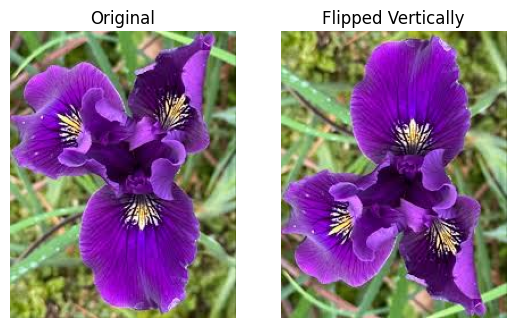

In [14]:
from torchvision import transforms
import matplotlib.pyplot as plt

vertical_flip = transforms.RandomVerticalFlip(p=1.0)

vflipped_image = vertical_flip(image)

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(vflipped_image)
plt.axis("off")
plt.title("Flipped Vertically")

plt.show()


## Step 4: Random Rotation

**Rotation** turns the image by a certain angle.  

- **Why use it?**  
  Helps the model recognize objects in different orientations.  
  Especially useful in tasks like traffic signs, medical images, or handwritten digits (MNIST).

- **Adjustable parameters:**  
  - `degrees` = maximum rotation angle (can be a single value or a range)  
    - `30` → rotates between -30° and +30°  
    - `(min, max)` → custom range  
  - Can be combined with other transformations for more variety


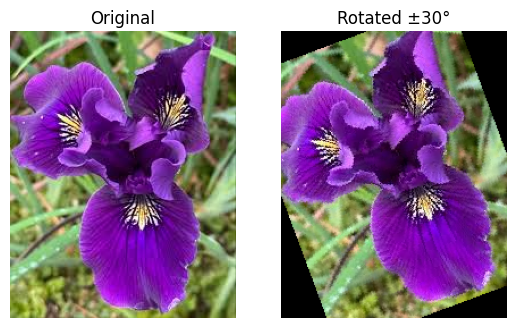

In [20]:
from torchvision import transforms
import matplotlib.pyplot as plt

#Change the values and re-run to see multiple variations
rotation = transforms.RandomRotation(degrees=30)  # Rotates randomly between ±30 degrees

rotated_image = rotation(image)

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(rotated_image)
plt.axis("off")
plt.title("Rotated ±30°")

plt.show()




## Step 5: Color Jitter (Brightness, Contrast, Saturation)

**Color Jitter** randomly changes the **brightness, contrast, saturation, and hue** of an image.  

- **Why use it?**  
  Makes models robust to **different lighting conditions** or camera settings.  

- **Adjustable parameters:**  
  - `brightness` = 0.0 → no change, 1.0 → full variation  
  - `contrast` = 0.0 → no change, 1.0 → full variation  
  - `saturation` = 0.0 → no change, 1.0 → full variation  
  - `hue` = 0.0 → no change, max 0.5 → changes hue drastically  

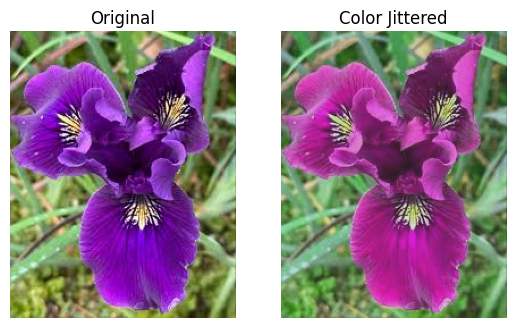

In [16]:
from torchvision import transforms
import matplotlib.pyplot as plt

color_jitter = transforms.ColorJitter(
    brightness=0.5,
    contrast=0.5,
    saturation=0.5,
    hue=0.1
)

jittered_image = color_jitter(image)

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(jittered_image)
plt.axis("off")
plt.title("Color Jittered")

plt.show()


## Step 6: Random Crop and Resize

**Random Crop** selects a random portion of the image and optionally resizes it back to the original size.  

- **Why use it?**  
  Helps the model learn to **focus on different parts** of the image.  
  Improves robustness when objects are **not always centered**.

- **Adjustable parameters:**  
  - `size` = final size of the image after crop  
  - `scale` = range of proportion of the original image to crop (e.g., 0.5 → crop at least 50% of original)  
  - `ratio` = aspect ratio range for the crop (e.g., (0.75, 1.33))

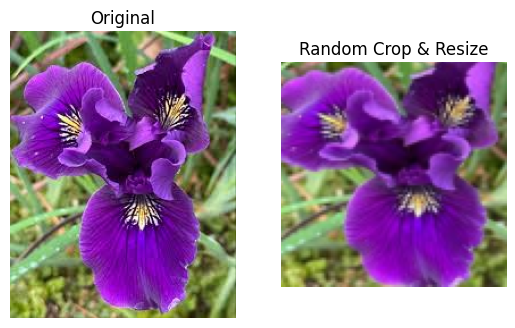

In [17]:
from torchvision import transforms
import matplotlib.pyplot as plt

random_crop = transforms.RandomResizedCrop(
    size=(100, 100),  # final size
    scale=(0.5, 1.0), # crop between 50%-100% of original
    ratio=(0.75, 1.33)
)

cropped_image = random_crop(image)

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.axis("off")
plt.title("Random Crop & Resize")

plt.show()

## Step 7: Gaussian Noise / Blur

**Gaussian Noise** adds random pixel-level variations, simulating sensor noise.  
**Gaussian Blur** smooths the image by averaging pixels.  

- **Why use it?**  
  Makes models **robust to noisy or blurry images**, common in real-world scenarios.  

- **Adjustable parameters:**  
  - Noise: `mean` = average noise, `std` = intensity of noise  
  - Blur: `kernel_size` = size of the smoothing window


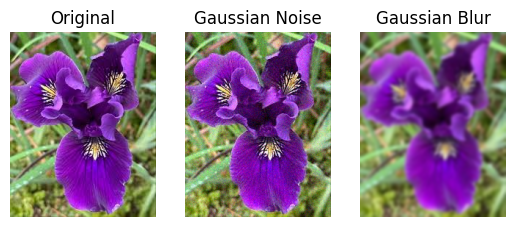

In [18]:
import numpy as np
from PIL import ImageFilter
import matplotlib.pyplot as plt

# Converting image to numpy array
img_array = np.array(image).astype(np.float32) / 255.0

# Adding Gaussian noise
mean = 0.0
std = 0.05
noise = np.random.normal(mean, std, img_array.shape)
noisy_array = np.clip(img_array + noise, 0, 1)  # Keep values between 0 to 1
noisy_image = Image.fromarray((noisy_array * 255).astype(np.uint8))

# Applying Gaussian blur
blurred_image = image.filter(ImageFilter.GaussianBlur(radius=2))  # radius = blur the intensity

# Displays original, noisy, and blurred images
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(noisy_image)
plt.axis("off")
plt.title("Gaussian Noise")

plt.subplot(1, 3, 3)
plt.imshow(blurred_image)
plt.axis("off")
plt.title("Gaussian Blur")

plt.show()
